# 1. Project Setup

This notebook performs the initial exploratory analysis (Phase 2A) of the fetal movement dataset.

The objectives of this notebook are to:

- Understand the overall dataset structure.
- Inspect recordings and metadata.
- Analyze recording statistics.
- Check data quality.
- Identify missing values.
- Prepare the dataset for the signal processing pipeline.

This notebook does **not** perform preprocessing or machine learning.

In [31]:
# ============================================================
# Project Setup
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib

warnings.filterwarnings("ignore")

# Better plotting
plt.style.use("ggplot")
matplotlib.rcParams["figure.figsize"] = (12, 5)

# ------------------------------------------------------------
# Project Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "m873dbhy9j-1"

print("="*60)
print("Fetal Movement Assessment Project")
print("="*60)

print(f"Project Root : {PROJECT_ROOT}")
print(f"Dataset Path : {DATASET_PATH}")

print("\nDataset Exists :", DATASET_PATH.exists())

Fetal Movement Assessment Project
Project Root : c:\Users\Asus\OneDrive\Desktop\fetal_assesment_project
Dataset Path : c:\Users\Asus\OneDrive\Desktop\fetal_assesment_project\data\raw\m873dbhy9j-1

Dataset Exists : True


# 2. Dataset Discovery

This section automatically explores the dataset directory and identifies:

- Files
- Subdirectories
- Metadata files
- Recording folders

This provides an overview of the dataset organization before loading any signals.

In [32]:
# ============================================================
# Dataset Discovery
# ============================================================

all_items = sorted(DATASET_PATH.iterdir())

folders = [item for item in all_items if item.is_dir()]
files = [item for item in all_items if item.is_file()]

print(f"Folders : {len(folders)}")
print(f"Files   : {len(files)}")

Folders : 1
Files   : 4


# 3. Dataset Structure

Each recording folder is inspected to understand:

- Number of recording files
- Metadata files
- File types
- Overall organization

In [33]:
# ============================================================
# Dataset Structure
# ============================================================

for folder in folders:

    print("\n" + "="*60)
    print(folder.name)
    print("="*60)

    contents = sorted(folder.iterdir())

    print(f"Total files : {len(contents)}\n")

    for file in contents[:10]:
        print(file.name)

    if len(contents) > 10:
        print("...")


Sub-dataset One
Total files : 17

record_1.csv
record_10.csv
record_11.csv
record_12.csv
record_13.csv
record_15.csv
record_16.csv
record_17.csv
record_2.csv
record_25.csv
...


In [34]:
recording_files = sorted(DATASET_PATH.glob("Sub-dataset One/record_*.csv"))

print(f"Total Recording Files : {len(recording_files)}")

for file in recording_files[:5]:
    print(file.name)


Total Recording Files : 17
record_1.csv
record_10.csv
record_11.csv
record_12.csv
record_13.csv


In [35]:
sample_file = recording_files[0]

print(f"Sample Recording : {sample_file.name}")

df = pd.read_csv(sample_file)

print(df.shape)

display(df.head())

print(sample_file.name)

df = pd.read_csv(sample_file)

print("\nShape")

print(df.shape)

print("\nColumns")

print(df.columns.tolist())

display(df.head())

Sample Recording : record_1.csv
(64500, 26)


,time,ax1,ay1,az1,gx1,gy1,gz1,ax2,ay2,az2,...,gx3,gy3,gz3,ax4,ay4,az4,gx4,gy4,gz4,label
0,0.000000,15740,3208,4616,-159,13,-15,15092,-7284,2508,...,-974,203,-100,12144,668,-11344,-549,83,-125,0
1,0.033672,15824,3268,4360,-185,-10,-249,15060,-7344,2556,...,-957,176,-103,12104,664,-11308,-542,133,-156,0
2,0.067500,15596,3272,4404,-116,-14,3,15032,-7308,2512,...,-1004,122,-55,11988,524,-11312,-483,90,-151,0
3,0.101268,15740,3204,4688,-138,-52,-255,15012,-7284,2536,...,-997,65,-59,12280,608,-11276,-502,127,-102,0
4,0.134621,15708,3152,4500,-155,255,49,15112,-7332,2752,...,-957,118,-49,12064,612,-11408,-536,249,-130,0


record_1.csv

Shape
(64500, 26)

Columns
['time', 'ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'ax3', 'ay3', 'az3', 'gx3', 'gy3', 'gz3', 'ax4', 'ay4', 'az4', 'gx4', 'gy4', 'gz4', 'label']


,time,ax1,ay1,az1,gx1,gy1,gz1,ax2,ay2,az2,...,gx3,gy3,gz3,ax4,ay4,az4,gx4,gy4,gz4,label
0,0.000000,15740,3208,4616,-159,13,-15,15092,-7284,2508,...,-974,203,-100,12144,668,-11344,-549,83,-125,0
1,0.033672,15824,3268,4360,-185,-10,-249,15060,-7344,2556,...,-957,176,-103,12104,664,-11308,-542,133,-156,0
2,0.067500,15596,3272,4404,-116,-14,3,15032,-7308,2512,...,-1004,122,-55,11988,524,-11312,-483,90,-151,0
3,0.101268,15740,3204,4688,-138,-52,-255,15012,-7284,2536,...,-997,65,-59,12280,608,-11276,-502,127,-102,0
4,0.134621,15708,3152,4500,-155,255,49,15112,-7332,2752,...,-957,118,-49,12064,612,-11408,-536,249,-130,0


# 4. Recording Statistics

For each recording, we compute:

- Number of samples
- Recording duration
- Number of columns

These statistics provide an overview of the dataset.

In [36]:
# ============================================================
# Recording Statistics
# ============================================================

stats = []

for file in csv_files:

    df = pd.read_csv(file)

    samples = len(df)

    duration = df.iloc[-1, 0] - df.iloc[0, 0]

    stats.append({
        "Recording": file.stem,
        "Samples": samples,
        "Duration (s)": duration,
        "Columns": df.shape[1]
    })

stats_df = pd.DataFrame(stats)

display(stats_df.head())

,Recording,Samples,Duration (s),Columns
0,record_1,64500,2173.947577,26
1,record_10,66391,2294.717595,26
2,record_11,22404,775.545075,26
3,record_12,52492,1815.284086,26
4,record_13,42291,1454.628846,26


In [37]:
print("="*60)

print("Recording Statistics")

print("="*60)

display(stats_df.describe())

Recording Statistics


,Samples,Duration (s),Columns
count,17.000000,17.000000,17.0
mean,38718.588235,1325.102170,26.0
std,19857.224784,672.981071,0.0
min,12612.000000,435.190273,26.0
25%,20551.000000,712.039396,26.0
50%,40179.000000,1360.343352,26.0
75%,55769.000000,1884.420180,26.0
max,67982.000000,2297.786629,26.0


# 5. Missing Value Analysis

Data quality is assessed by checking:

- Missing values
- Duplicate rows
- Infinite values

A clean dataset reduces preprocessing complexity.

In [38]:
# ============================================================
# Missing Values
# ============================================================

quality = []

for file in csv_files:

    df = pd.read_csv(file)

    quality.append({
        "Recording": file.stem,
        "Missing Values": df.isna().sum().sum(),
        "Duplicate Rows": df.duplicated().sum(),
        "Infinite Values": np.isinf(df.select_dtypes(include=np.number)).sum().sum()
    })

quality_df = pd.DataFrame(quality)

display(quality_df.head())

,Recording,Missing Values,Duplicate Rows,Infinite Values
0,record_1,0,0,0
1,record_10,0,0,0
2,record_11,0,0,0
3,record_12,0,0,0
4,record_13,0,0,0


In [39]:
print("="*60)

print("Dataset Quality Summary")

print("="*60)

print(f"Total Missing Values : {quality_df['Missing Values'].sum()}")

print(f"Total Duplicate Rows : {quality_df['Duplicate Rows'].sum()}")

print(f"Total Infinite Values : {quality_df['Infinite Values'].sum()}")

Dataset Quality Summary
Total Missing Values : 0
Total Duplicate Rows : 0
Total Infinite Values : 0


# 6. Label Analysis

This section analyzes the distribution of fetal movement labels across all recordings.

Objectives:
- Count movement and non-movement samples.
- Measure class imbalance.
- Compute label percentages.
- Analyze label distribution per recording.

In [40]:
# ============================================================
# Locate all recording files
# ============================================================

recording_files = sorted(
    (DATASET_PATH / "Sub-dataset One").glob("record_*.csv")
)

print(f"Total Recording Files : {len(recording_files)}")

for file in recording_files[:5]:
    print(file.name)

Total Recording Files : 17
record_1.csv
record_10.csv
record_11.csv
record_12.csv
record_13.csv


In [41]:
# ============================================================
# Label Distribution
# ============================================================

label_summary = []

for file in recording_files:

    df = pd.read_csv(file)

    movement = (df["label"] == 1).sum()
    no_movement = (df["label"] == 0).sum()

    label_summary.append({
        "Recording": file.stem,
        "Movement": movement,
        "No Movement": no_movement,
        "Total Samples": len(df)
    })

label_df = pd.DataFrame(label_summary)

display(label_df.head())

,Recording,Movement,No Movement,Total Samples
0,record_1,0,64500,64500
1,record_10,0,66313,66391
2,record_11,4,22316,22404
3,record_12,11,52340,52492
4,record_13,0,42263,42291


In [42]:
total_movement = label_df["Movement"].sum()
total_no_movement = label_df["No Movement"].sum()

print("="*60)
print("Overall Label Distribution")
print("="*60)

print(f"Movement Samples     : {total_movement:,}")
print(f"No Movement Samples  : {total_no_movement:,}")

total = total_movement + total_no_movement

print(f"\nMovement %     : {100*total_movement/total:.2f}%")
print(f"No Movement %  : {100*total_no_movement/total:.2f}%")

Overall Label Distribution
Movement Samples     : 72
No Movement Samples  : 656,429

Movement %     : 0.01%
No Movement %  : 99.99%


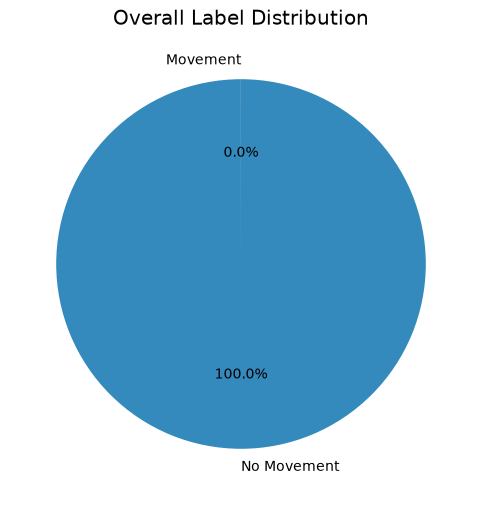

In [43]:
plt.figure(figsize=(6,6))

plt.pie(
    [total_movement, total_no_movement],
    labels=["Movement","No Movement"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Label Distribution")

plt.show()

# 7. Sampling Rate Analysis

The sampling frequency is calculated directly from the timestamps instead of relying on documentation.

In [44]:
# ============================================================
# Sampling Rate Analysis
# ============================================================

sample = pd.read_csv(recording_files[0])

dt = sample["time"].diff().dropna()

sampling_rate = 1 / dt.mean()

print("="*60)
print("Sampling Statistics")
print("="*60)

print(f"Average Δt      : {dt.mean():.6f} sec")
print(f"Sampling Rate   : {sampling_rate:.2f} Hz")

print(f"Minimum Δt      : {dt.min():.6f}")
print(f"Maximum Δt      : {dt.max():.6f}")

Sampling Statistics
Average Δt      : 0.033705 sec
Sampling Rate   : 29.67 Hz
Minimum Δt      : 0.032713
Maximum Δt      : 1.162219


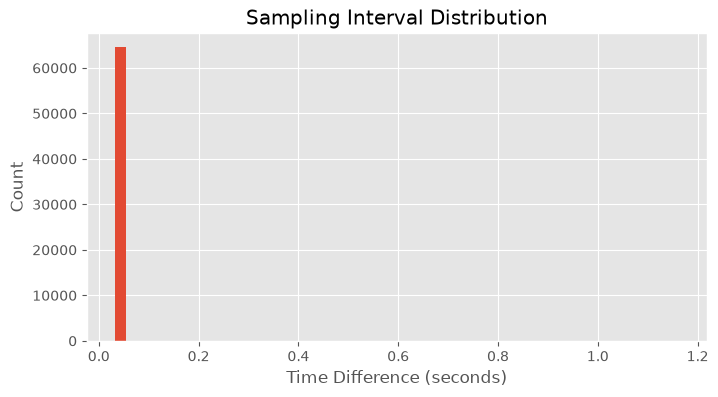

In [45]:
plt.figure(figsize=(8,4))

plt.hist(dt, bins=50)

plt.title("Sampling Interval Distribution")

plt.xlabel("Time Difference (seconds)")
plt.ylabel("Count")

plt.show()

# 8. Signal Visualization

Visualize raw accelerometer signals and overlay fetal movement labels.

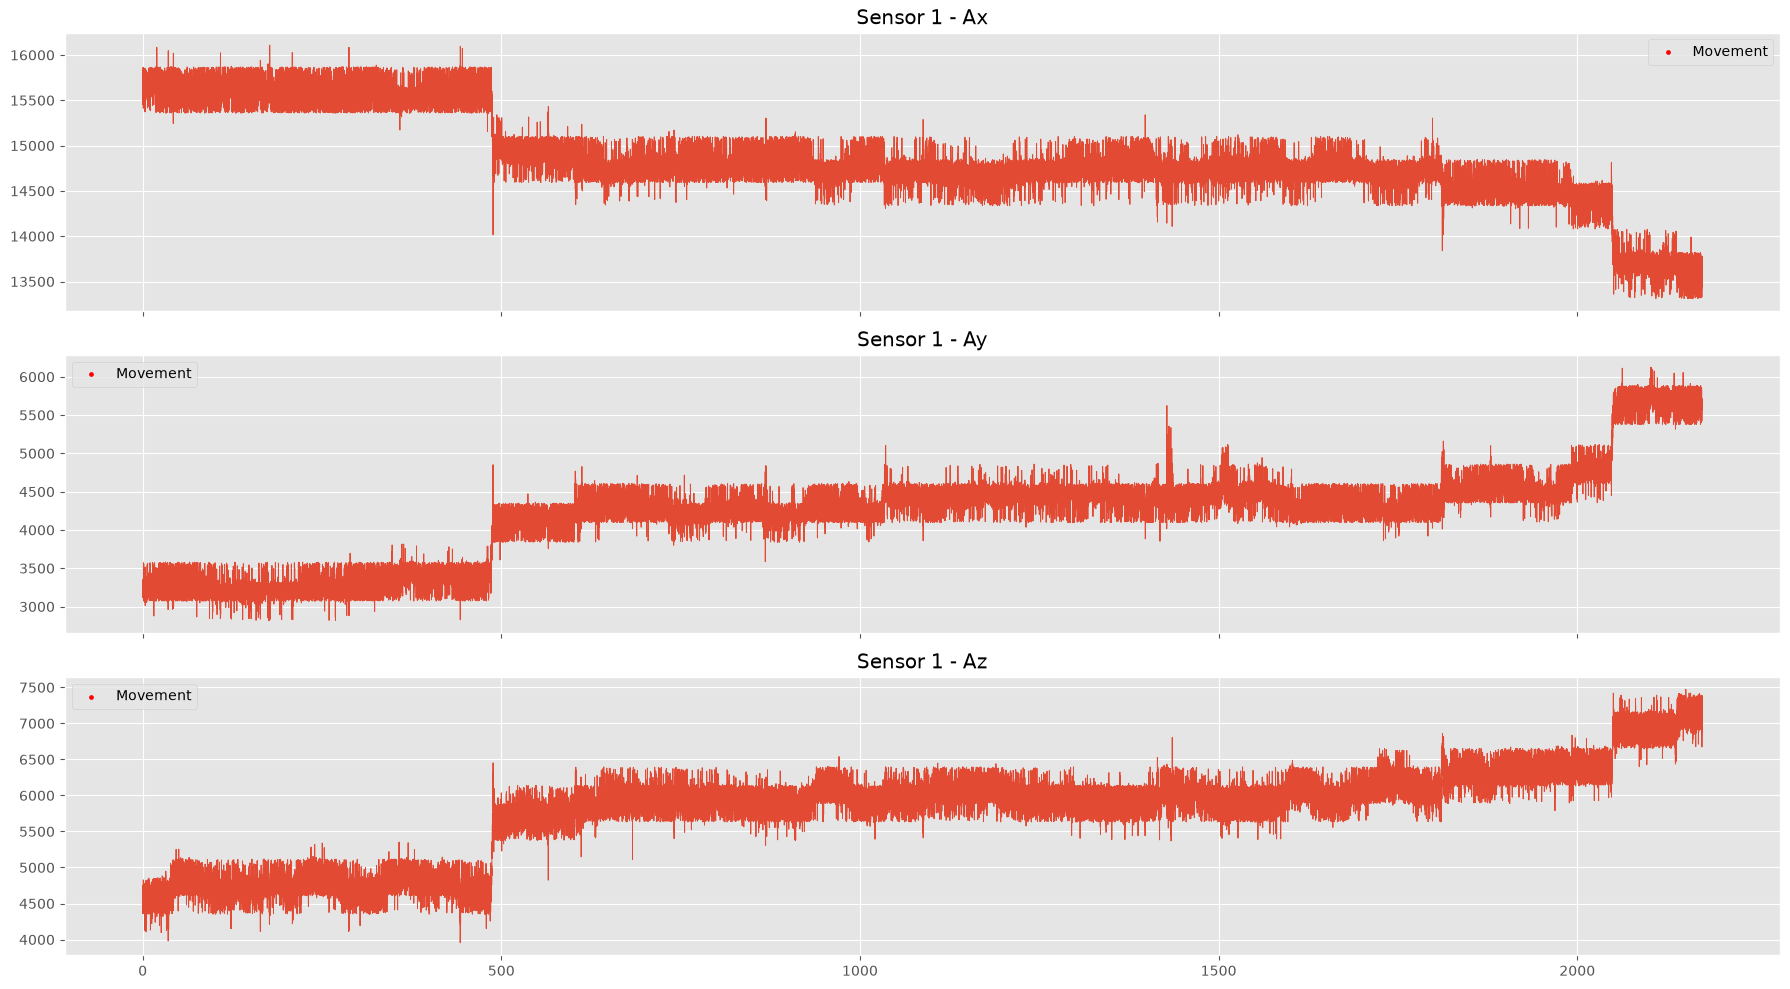

In [46]:
sample = pd.read_csv(recording_files[0])

fig, axes = plt.subplots(3,1, figsize=(18,10), sharex=True)

axes[0].plot(sample["time"], sample["ax1"], linewidth=0.7)
axes[0].set_title("Sensor 1 - Ax")

axes[1].plot(sample["time"], sample["ay1"], linewidth=0.7)
axes[1].set_title("Sensor 1 - Ay")

axes[2].plot(sample["time"], sample["az1"], linewidth=0.7)
axes[2].set_title("Sensor 1 - Az")

movement_idx = sample["label"] == 1

for ax in axes:
    ax.scatter(
        sample.loc[movement_idx,"time"],
        ax.lines[0].get_ydata()[movement_idx],
        s=8,
        c="red",
        label="Movement"
    )
    ax.legend()

plt.tight_layout()
plt.show()

# 9. Sensor Correlation Analysis

Correlation analysis identifies redundant sensors and relationships between channels.

In [47]:
# ============================================================
# Sensor Correlation Analysis
# ============================================================

sample = pd.read_csv(recording_files[0])

sensor_columns = sample.columns.drop(["time", "label"])

corr = sample[sensor_columns].corr()

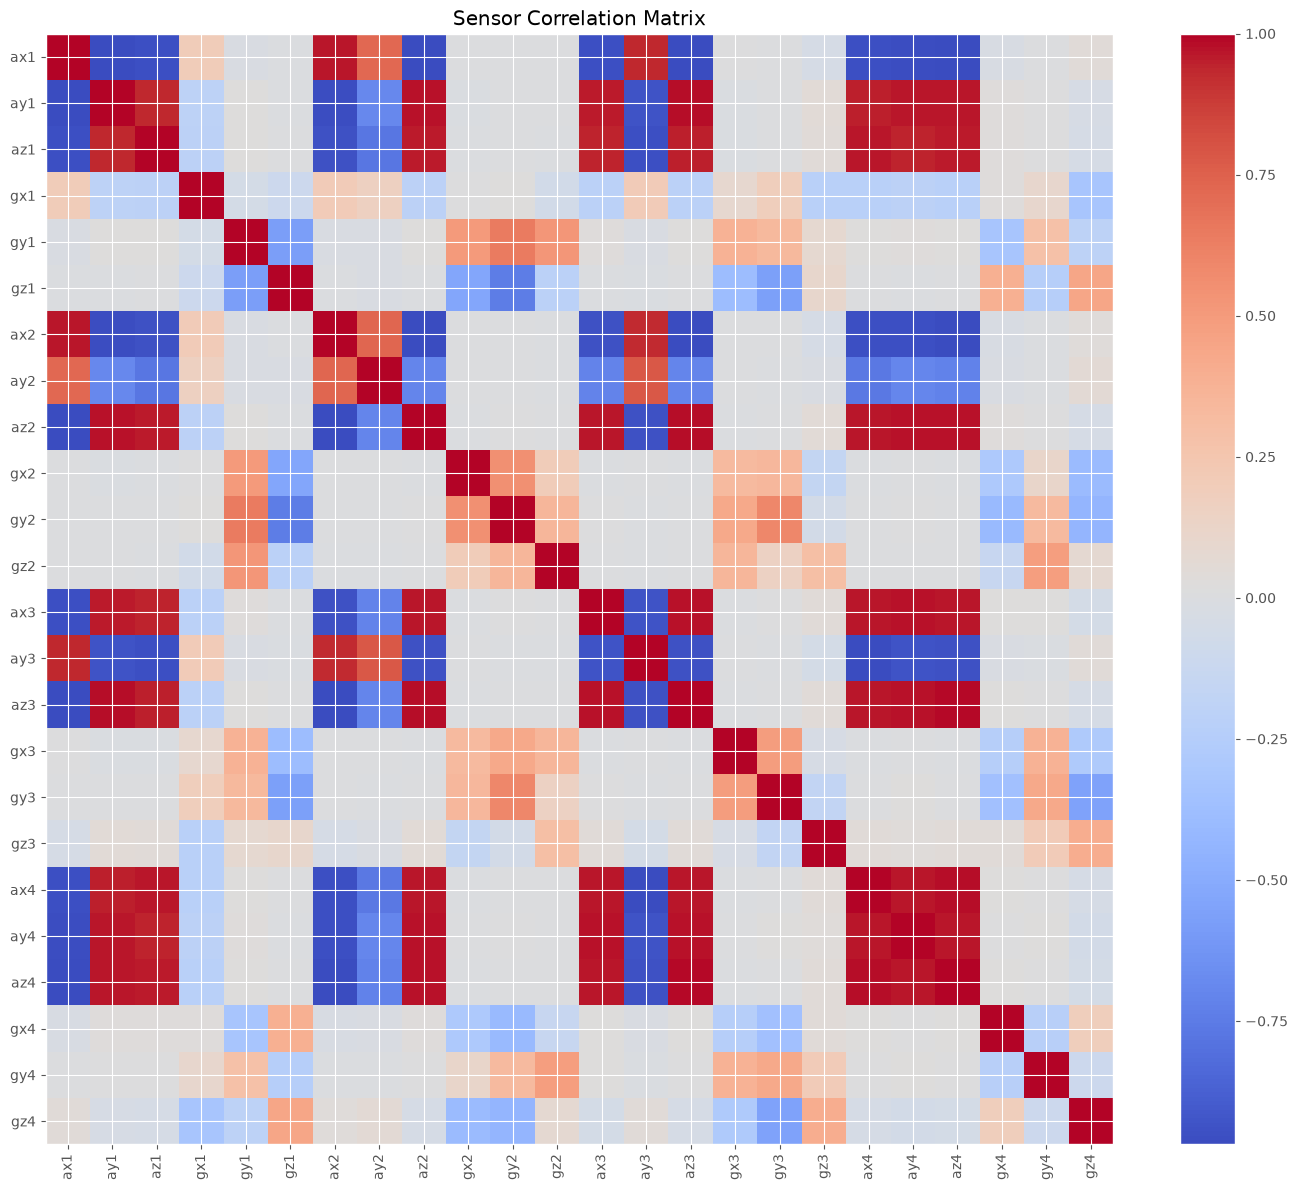

In [48]:
plt.figure(figsize=(14,12))

plt.imshow(corr, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.xticks(range(len(sensor_columns)), sensor_columns, rotation=90)
plt.yticks(range(len(sensor_columns)), sensor_columns)

plt.title("Sensor Correlation Matrix")

plt.tight_layout()

plt.show()

In [49]:
variance = sample[sensor_columns].var().sort_values(ascending=False)

display(variance.to_frame("Variance"))

,Variance
az4,2.133406e+06
az3,1.500753e+06
ax4,8.916211e+05
az2,7.762671e+05
az1,4.026490e+05
ax3,3.741764e+05
ay1,3.594949e+05
ay4,3.378780e+05
ay3,2.914937e+05
ax1,2.383420e+05
